# LSTM Stock Price Direction Prediction

## Objectives

- Prepare sequential data for LSTM
- Build and train an LSTM model
- Evaluate prediction accuracy
- Compare deep learning with traditional machine learning

In [1]:
%pip install tensorflow

   ---------------------------------------- 0.0/350.9 MB ? eta -:--:--
   ---------------------------------------- 0.0/350.9 MB ? eta -:--:--
   ---------------------------------------- 0.3/350.9 MB ? eta -:--:--
   ---------------------------------------- 0.5/350.9 MB 1.9 MB/s eta 0:03:09
   ---------------------------------------- 0.5/350.9 MB 1.9 MB/s eta 0:03:09
   ---------------------------------------- 0.8/350.9 MB 714.3 kB/s eta 0:08:11
   ---------------------------------------- 1.0/350.9 MB 838.4 kB/s eta 0:06:58
   ---------------------------------------- 1.0/350.9 MB 838.4 kB/s eta 0:06:58
   ---------------------------------------- 1.0/350.9 MB 838.4 kB/s eta 0:06:58
   ---------------------------------------- 1.0/350.9 MB 838.4 kB/s eta 0:06:58
   ---------------------------------------- 1.3/350.9 MB 599.2 kB/s eta 0:09:44
   ---------------------------------------- 1.3/350.9 MB 599.2 kB/s eta 0:09:44
   ---------------------------------------- 1.6/350.9 MB 616.8 kB/s eta


[notice] A new release of pip is available: 25.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import numpy as np
import pandas as pd

from sklearn.preprocessing import MinMaxScaler

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import Dropout

In [3]:
stock = pd.read_csv(
    "../data/processed/reliance_advanced_features.csv",
    parse_dates=["Date"]
)

stock.head()

,Date,Adj Close,Close,High,Low,Open,Volume,Daily_Return,Log_Return,Trading_Range,...,MA200,EMA20,Target,RSI,MACD,MACD_Signal,BB_Upper,BB_Lower,BB_Width,Momentum10
0,2015-11-20,204.222931,216.433975,217.794052,211.565155,213.496689,11304265,0.012945,0.012862,6.228897,...,208.368368,213.480029,1,51.550482,-1.221252,-1.031852,221.865864,209.212293,12.653571,-1.017197
1,2015-11-23,205.711151,218.011200,218.959824,216.285400,217.154022,10499517,0.007287,0.007261,2.674423,...,208.396198,213.911569,1,51.601790,-0.842501,-0.993982,221.826597,209.222987,12.603610,3.920197
2,2015-11-24,208.720001,221.199936,222.091415,217.394028,217.839767,14806176,0.014626,0.014521,4.697388,...,208.456144,214.605699,1,52.071310,-0.281785,-0.851542,222.342142,208.982884,13.359258,3.497314
3,2015-11-26,213.238602,225.988754,226.743088,221.325668,221.954269,23805828,0.021649,0.021418,5.417419,...,208.548263,215.689800,0,55.250916,0.542747,-0.572684,224.304350,208.067586,16.236764,6.263168
4,2015-11-27,211.168030,223.794357,226.868805,222.662872,226.068756,10891864,-0.009710,-0.009758,4.205933,...,208.595637,216.461662,0,57.009350,1.007512,-0.256645,225.401663,207.873177,17.528486,12.869232


In [4]:
features = [
    "Close",
    "Volume",
    "RSI",
    "MACD",
    "Momentum10"
]

data = stock[features]

In [5]:
scaler = MinMaxScaler()

scaled_data = scaler.fit_transform(data)

In [6]:
sequence_length = 20

X = []
y = []

for i in range(sequence_length, len(scaled_data)):
    X.append(scaled_data[i-sequence_length:i])
    y.append(stock["Target"].iloc[i])

X = np.array(X)
y = np.array(y)

print(X.shape)
print(y.shape)

(2228, 20, 5)
(2228,)


In [7]:
split = int(len(X) * 0.8)

X_train = X[:split]
X_test = X[split:]

y_train = y[:split]
y_test = y[split:]

In [8]:
model = Sequential()

model.add(
    LSTM(
        50,
        return_sequences=False,
        input_shape=(X_train.shape[1], X_train.shape[2])
    )
)

model.add(Dropout(0.2))

model.add(Dense(1, activation="sigmoid"))

model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

model.summary()

c:\Users\taart\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 50)             │        11,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 50)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,251 (43.95 KB)

 Trainable params: 11,251 (43.95 KB)

 Non-trainable params: 0 (0.00 B)

In [9]:
history = model.fit(
    X_train,
    y_train,
    epochs=20,
    batch_size=32,
    validation_split=0.2,
    verbose=1
)

Epoch 1/20
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.5165 - loss: 0.6926 - val_accuracy: 0.5014 - val_loss: 0.6981
Epoch 2/20
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.5109 - loss: 0.6944 - val_accuracy: 0.5014 - val_loss: 0.6958
Epoch 3/20
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.5137 - loss: 0.6938 - val_accuracy: 0.5014 - val_loss: 0.6977
Epoch 4/20
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.5158 - loss: 0.6933 - val_accuracy: 0.5014 - val_loss: 0.6959
Epoch 5/20
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.5256 - loss: 0.6920 - val_accuracy: 0.5014 - val_loss: 0.6966
Epoch 6/20
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.5053 - loss: 0.6942 - val_accuracy: 0.5014 - val_loss: 0.6948
Epoch 7/20
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.5123 - loss: 0.6956 - val_accuracy: 0.5014 - val_loss: 0.6953
Epoch 8/20
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.5242 - loss: 0.6936 - val_accuracy: 0.5014 - val_loss

In [10]:
loss, accuracy = model.evaluate(
    X_test,
    y_test
)

print("Test Accuracy:", round(accuracy,4))

14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.5224 - loss: 0.6925
Test Accuracy: 0.5224


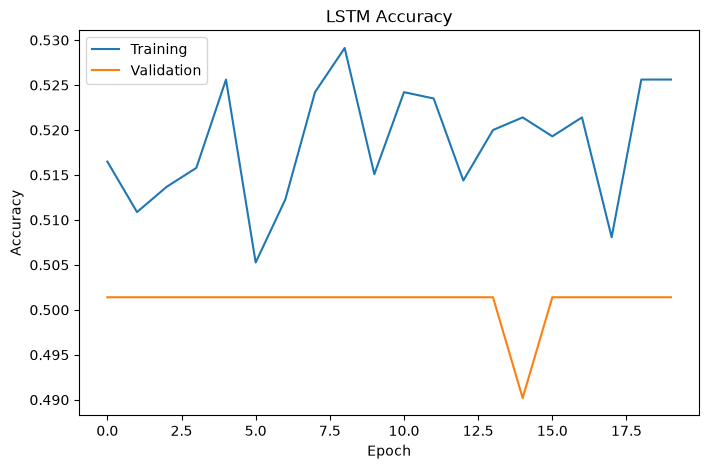

In [11]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.plot(history.history["accuracy"], label="Training")

plt.plot(history.history["val_accuracy"], label="Validation")

plt.title("LSTM Accuracy")

plt.xlabel("Epoch")

plt.ylabel("Accuracy")

plt.legend()

plt.show()

## Conclusion

### Key Findings

- Built an LSTM model for stock direction prediction.
- Used sequential historical data rather than independent observations.
- Compared deep learning performance with traditional machine learning models.
- Observed whether sequence-based learning improved predictive accuracy.